## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("All libraries loaded!")

All libraries loaded!


## 2. Load Data

In [32]:
df = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2010-2011')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (541910, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [33]:
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

Data types:
 Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object


## 3. Data Cleaning

In [34]:
# Step 1: Remove rows where Customer ID is missing
df = df.dropna(subset=['Customer ID'])

# Step 2: Convert Customer ID to integer then string
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)

# Step 3: Remove cancelled orders (Invoice starts with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Step 4: Keep only positive quantities and prices
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

print("Clean data shape:", df.shape)

Clean data shape: (397885, 8)


## 4. Compute RFM Metrics

In [35]:
# Set the reference date (day after last transaction in dataset)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create a new column: revenue per row
df['TotalPrice'] = df['Quantity'] * df['Price']

# Calculate R, F, M for each customer
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print(rfm.shape)
rfm.head(10)

(4338, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [36]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.270609
std,100.014169,7.697998,8989.229895
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


## 5. RFM Scoring (1–5 scale)

In [37]:
# For Recency: LOWER days = BETTER = score 5
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# For Frequency: HIGHER = BETTER = score 5
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# For Monetary: HIGHER = BETTER = score 5
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Combine into one RFM score string e.g. "555" = best customer
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score']].head(10))

  Customer ID  Recency  Frequency  Monetary RFM_Score
0       12346      326          1  77183.60       115
1       12347        2          7   4310.00       555
2       12348       75          4   1797.24       244
3       12349       19          1   1757.55       414
4       12350      310          1    334.40       112
5       12352       36          8   2506.04       355
6       12353      204          1     89.00       111
7       12354      232          1   1079.40       114
8       12355      214          1    459.40       112
9       12356       23          3   2811.43       435


## 6. Customer Segmentation

In [38]:
def assign_segment(score):
    r = int(score[0])
    f = int(score[1])
    m = int(score[2])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal Customer'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'Promising'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cannot Lose Them'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(assign_segment)

print(rfm['Segment'].value_counts())

Segment
Loyal Customer      998
Champion            962
Lost                927
At Risk             643
New Customer        319
Promising           248
Cannot Lose Them    241
Name: count, dtype: int64


## 7. Visualisations

In [39]:
seg_colors = {
    'Champion': '#4ade80',
    'Loyal Customer': '#60a5fa',
    'New Customer': '#a78bfa',
    'Promising': '#fbbf24',
    'At Risk': '#f87171',
    'Cannot Lose Them': '#f472b6',
    'Lost': '#6b7280'
}

# Segment distribution — pie chart
seg_count = rfm['Segment'].value_counts().reset_index()
seg_count.columns = ['Segment', 'Count']

fig = px.pie(seg_count, names='Segment', values='Count',
             color='Segment', color_discrete_map=seg_colors,
             hole=0.45, title='Customer Segment Distribution')
fig.show()

In [41]:
# Revenue by segment — horizontal bar chart
seg_rev = rfm.groupby('Segment')['Monetary'].sum().reset_index()
seg_rev.columns = ['Segment', 'Revenue']
seg_rev = seg_rev.sort_values('Revenue', ascending=True)

fig2 = px.bar(seg_rev, x='Revenue', y='Segment', orientation='h',
              color='Segment', color_discrete_map=seg_colors,
              title='Total Revenue by Segment')
fig2.show()

In [40]:
# Recency vs Monetary scatter plot
fig3 = px.scatter(rfm, x='Recency', y='Monetary', color='Segment',
                  color_discrete_map=seg_colors, opacity=0.6,
                  hover_data=['Customer ID', 'Frequency'],
                  title='Recency vs Monetary Value by Segment')
fig3.show()

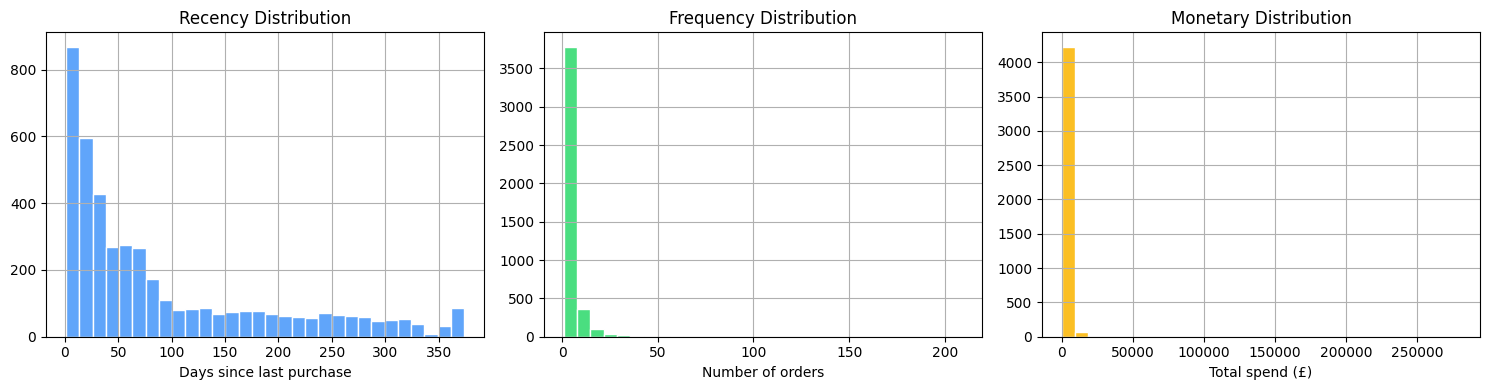

In [42]:
# RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rfm['Recency'].hist(ax=axes[0], bins=30, color='#60a5fa', edgecolor='white')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last purchase')

rfm['Frequency'].hist(ax=axes[1], bins=30, color='#4ade80', edgecolor='white')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of orders')

rfm['Monetary'].hist(ax=axes[2], bins=30, color='#fbbf24', edgecolor='white')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total spend (£)')

plt.tight_layout()
plt.show()

## 8. Export Results

In [43]:
rfm.to_csv('../data/rfm_segments.csv', index=False)
print("Saved! rfm_segments.csv is in your data folder.")
print(f"\nFinal dataset: {rfm.shape[0]} customers across {rfm['Segment'].nunique()} segments")
rfm.head()

Saved! rfm_segments.csv is in your data folder.

Final dataset: 4338 customers across 7 segments


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,5,115,Cannot Lose Them
1,12347,2,7,4310.00,5,5,5,555,Champion
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,New Customer
4,12350,310,1,334.40,1,1,2,112,Lost
